# Прогноз топливной экономичности автомобилей с помощью нейронной сети

В этой работе я решаю задачу регрессии: по характеристикам автомобиля нужно предсказать его топливную экономичность `MPG`.

Что я сделаю:
- загружу и подготовлю данные;
- разделю выборку на обучение и тест;
- нормализую признаки;
- обучу несколько моделей;
- в конце выберу нейросеть как основную модель и оценю её качество по метрикам **MSE** и **MAE**.

## 1. Подключение библиотек

Сначала подключаю библиотеки для работы с данными, графиками и нейронными сетями.

In [1]:
!pip install -q seaborn

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

np.set_printoptions(precision=3, suppress=True)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Загрузка данных

Использую датасет **Auto MPG**.  
Целевая переменная здесь — `MPG`, то есть топливная экономичность автомобиля.

In [3]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

column_names = [
    'MPG', 'Cylinders', 'Displacement', 'Horsepower',
    'Weight', 'Acceleration', 'Model Year', 'Origin'
]

raw_dataset = pd.read_csv(
    url,
    names=column_names,
    na_values='?',
    comment='\t',
    sep=' ',
    skipinitialspace=True
)

raw_dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


Посмотрю на пропуски. Это важно, потому что модель не сможет обучаться на пустых значениях.

In [4]:
raw_dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,6
Weight,0
Acceleration,0
Model Year,0
Origin,0


## 3. Очистка и подготовка данных

Удаляю строки с пропусками, чтобы упростить решение.

Также признак `Origin` является категориальным: это не число, а категория.  
Поэтому переведу его в набор отдельных бинарных признаков.

In [5]:
dataset = raw_dataset.dropna().copy()

dataset['Origin'] = dataset['Origin'].map({
    1: 'USA',
    2: 'Europe',
    3: 'Japan'
})

dataset = pd.get_dummies(
    dataset,
    columns=['Origin'],
    prefix='',
    prefix_sep='',
    dtype=float
)

dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,0.0,0.0,1.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,1.0,0.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,0.0,0.0,1.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,0.0,0.0,1.0
397,31.0,4,119.0,82.0,2720.0,19.4,82,0.0,0.0,1.0


## 4. Разделение на обучающую и тестовую выборки

Обучающая выборка нужна для обучения модели.  
Тестовая нужна для честной проверки качества на новых данных.

In [6]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

print("Размер train:", train_dataset.shape)
print("Размер test:", test_dataset.shape)

Размер train: (314, 10)
Размер test: (78, 10)


Посмотрю на несколько зависимостей между признаками и целевой переменной.

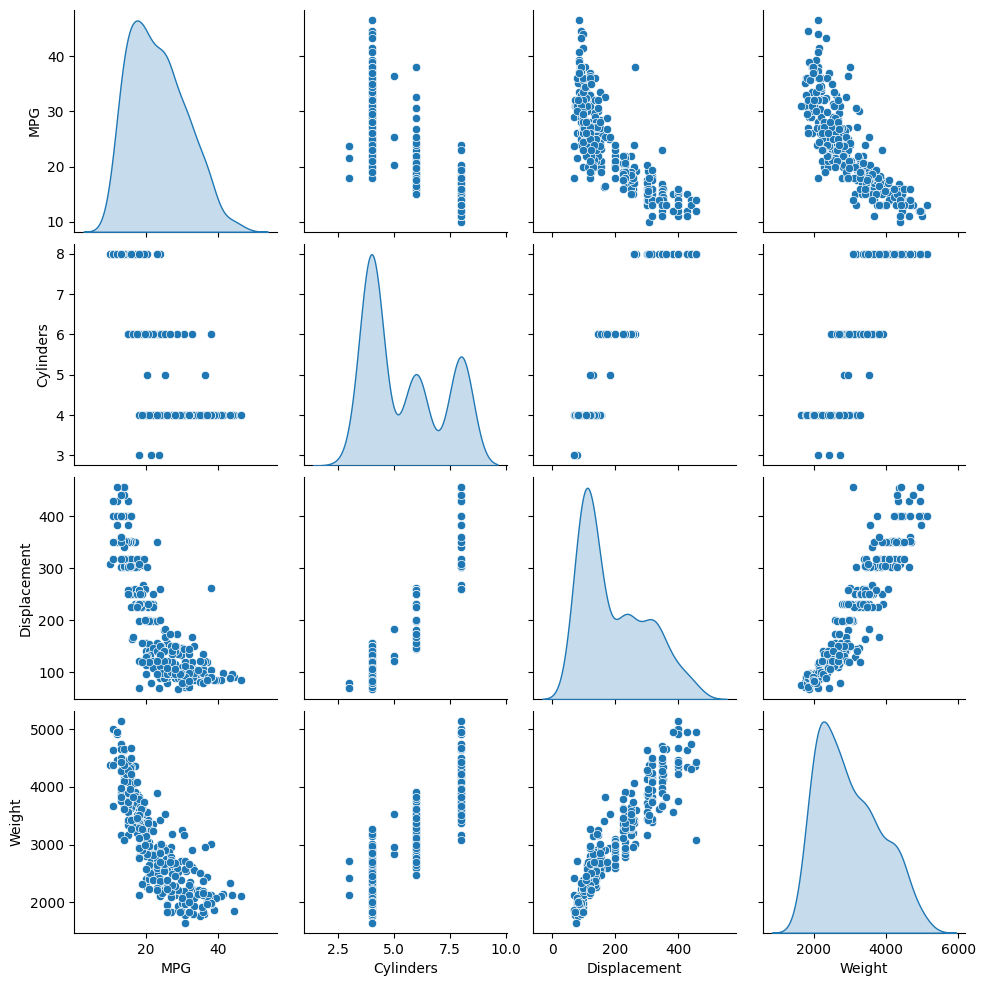

In [7]:
sns.pairplot(train_dataset[['MPG', 'Cylinders', 'Displacement', 'Weight']], diag_kind='kde')
plt.show()

Также полезно посмотреть основные статистики по признакам.

In [8]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0
Europe,314.0,0.178344,0.383413,0.0,0.00,0.0,0.00,1.0
Japan,314.0,0.197452,0.398712,0.0,0.00,0.0,0.00,1.0
USA,314.0,0.624204,0.485101,0.0,0.00,1.0,1.00,1.0


## 5. Отделение признаков от целевой переменной

Модель должна получать на вход признаки, а целевое значение `MPG` предсказывать.

In [9]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

print("Признаки train:", train_features.shape)
print("Целевая переменная train:", train_labels.shape)

Признаки train: (314, 9)
Целевая переменная train: (314,)


## 6. Нормализация признаков

Признаки имеют разные масштабы: где-то значения небольшие, где-то большие.  
Для нейронной сети это неудобно, поэтому делаю нормализацию.

In [10]:
train_features.describe().transpose()[['mean', 'std']]

,mean,std
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642
Europe,0.178344,0.383413
Japan,0.197452,0.398712
USA,0.624204,0.485101


In [11]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))

print("Средние значения после адаптации слоя:")
print(normalizer.mean.numpy())

Средние значения после адаптации слоя:
[[   5.478  195.318  104.869 2990.252   15.559   75.898    0.178    0.197
     0.624]]


Проверю, как слой нормализации преобразует одну строку данных.

In [12]:
first = np.array(train_features[:1])

with np.printoptions(precision=2, suppress=True):
    print("Первый объект:")
    print(first)
    print()
    print("После нормализации:")
    print(normalizer(first).numpy())

Первый объект:
[[   4.    90.    75.  2125.    14.5   74.     0.     0.     1. ]]

После нормализации:
[[-0.87 -1.01 -0.79 -1.03 -0.38 -0.52 -0.47 -0.5   0.78]]


## 7. Линейная модель по одному признаку

Сначала строю самый простой базовый вариант: предсказываю `MPG` только по признаку `Horsepower`.

Это не итоговое решение, а базовая модель для сравнения.

In [13]:
horsepower = np.array(train_features['Horsepower'])

horsepower_normalizer = layers.Normalization(input_shape=[1,], axis=None)
horsepower_normalizer.adapt(horsepower)

horsepower_model = tf.keras.Sequential([
    horsepower_normalizer,
    layers.Dense(units=1)
])

horsepower_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

In [14]:
horsepower_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)

Обучаю модель и сохраняю историю ошибки по эпохам.

In [15]:
%%time
history = horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

CPU times: user 11.5 s, sys: 420 ms, total: 12 s
Wall time: 12.9 s


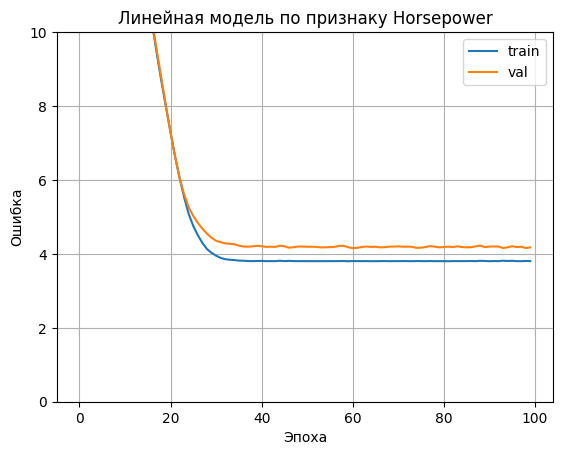

In [16]:
def plot_loss(history, title):
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.ylim([0, 10])
    plt.xlabel('Эпоха')
    plt.ylabel('Ошибка')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(history, 'Линейная модель по признаку Horsepower')

### Линейная модель по одному признаку (Horsepower)
График ошибки:

ошибка быстро уменьшается в начале и стабилизируется;
train и val близки → переобучения нет;
но ошибка довольно высокая (~4).


Посмотрю, как простая линейная модель описывает зависимость `MPG` от `Horsepower`.

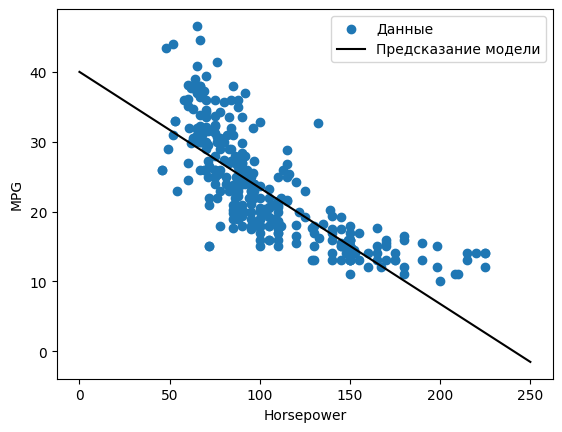

In [17]:
x = tf.linspace(0.0, 250, 251)
y = horsepower_model.predict(x, verbose=0)

plt.scatter(train_features['Horsepower'], train_labels, label='Данные')
plt.plot(x, y, color='black', label='Предсказание модели')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend()
plt.show()

График зависимости:
видим линейную зависимость: чем больше мощность, тем меньше MPG;
но точки сильно разбросаны → одного признака недостаточно.

Вывод: модель слишком простая, плохо описывает данные.

## 8. Линейная модель по всем признакам

Теперь использую уже все признаки сразу.  
Обычно это даёт лучшее качество, чем модель по одному признаку.

In [18]:
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])

linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)

linear_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (314, 9)               │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

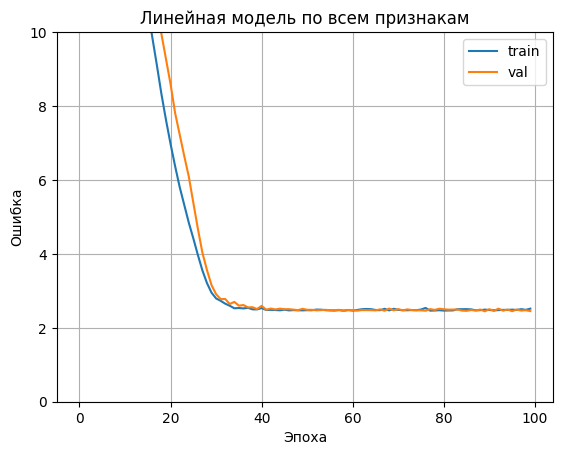

CPU times: user 11.6 s, sys: 438 ms, total: 12.1 s
Wall time: 13.5 s


In [19]:
%%time
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

plot_loss(history, 'Линейная модель по всем признакам')

Линейная модель по всем признакам

ошибка заметно ниже (~2.5);
train и val почти совпадают → модель обобщает хорошо;
обучение быстро сходится.

Вывод: добавление признаков сильно улучшило качество.

## 9. Нейронная сеть для регрессии

Теперь строю более мощную модель — полносвязную нейронную сеть.  
У неё два скрытых слоя, поэтому она может находить более сложные зависимости в данных.

In [20]:
def build_and_compile_model(norm):
    model = keras.Sequential([
        norm,
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='mean_absolute_error'
    )
    return model

Сначала обучу нейросеть только по одному признаку `Horsepower`, чтобы сравнить её с простой линейной моделью.

In [21]:
dnn_horsepower_model = build_and_compile_model(horsepower_normalizer)
dnn_horsepower_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,356 (17.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 3 (16.00 B)

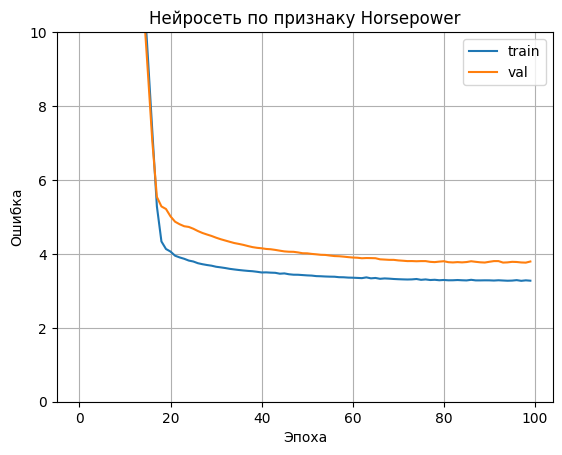

CPU times: user 12.4 s, sys: 518 ms, total: 12.9 s
Wall time: 13.3 s


In [22]:
%%time
history = dnn_horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=100
)

plot_loss(history, 'Нейросеть по признаку Horsepower')

Нейросеть по одному признаку

ошибка немного ниже, чем у линейной модели по одному признаку;
но всё равно остаётся высокой (~3.5–4);
переобучения нет (кривые близки).

Вывод: даже нейросеть не помогает, если мало признаков

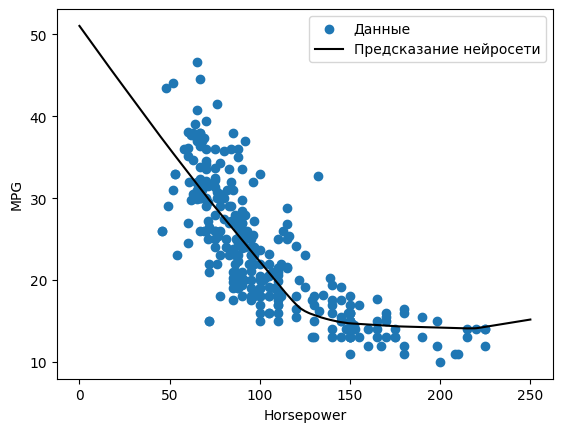

In [23]:
x = tf.linspace(0.0, 250, 251)
y = dnn_horsepower_model.predict(x, verbose=0)

plt.scatter(train_features['Horsepower'], train_labels, label='Данные')
plt.plot(x, y, color='black', label='Предсказание нейросети')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend()
plt.show()

## 10. Итоговая нейросеть по всем признакам

Это основная модель для задания, потому что она использует все признаки автомобиля.

In [24]:
dnn_model = build_and_compile_model(normalizer)
dnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

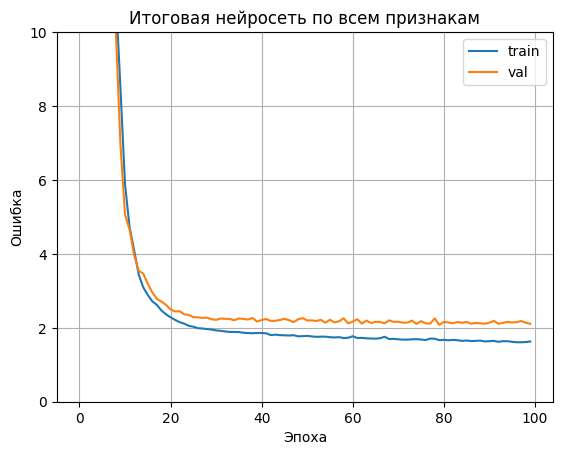

CPU times: user 13.1 s, sys: 531 ms, total: 13.7 s
Wall time: 13.9 s


In [25]:
%%time
history = dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=100
)

plot_loss(history, 'Итоговая нейросеть по всем признакам')

Итоговая нейросеть по всем признакам

самая низкая ошибка (~1.7–2);
train чуть ниже val → лёгкое переобучение, но норм;
модель стабильно обучилась.

Вывод: это лучшая модель из всех.

## 11. Оценка качества модели

По условию задания нужно оценить качество по двум метрикам:
- **MSE** — среднеквадратическая ошибка;
- **MAE** — средняя абсолютная ошибка.

MAE дополнительно считаю через `tf.losses.MeanAbsoluteError()`.

In [26]:
test_predictions = dnn_model.predict(test_features, verbose=0).flatten()

mse_metric = tf.keras.metrics.MeanSquaredError()
mse = mse_metric(test_labels, test_predictions).numpy()

mae_loss = tf.losses.MeanAbsoluteError()
mae = mae_loss(test_labels, test_predictions).numpy()

print(f"MSE на тестовой выборке: {mse:.4f}")
print(f"MAE на тестовой выборке: {mae:.4f}")

MSE на тестовой выборке: 5.3884
MAE на тестовой выборке: 1.7546


Метрики

* MSE ≈ 5.39
* MAE ≈ 1.75

Интерпретация:
в среднем ошибка прогноза ≈ 1.75 MPG — это достаточно хорошее качество.

Для сравнения покажу качество и других моделей по MAE.  
Но основной вывод по заданию делаю именно для итоговой нейросети `dnn_model`.

In [27]:
test_results = {}

test_results['Линейная модель (1 признак)'] = horsepower_model.evaluate(
    test_features['Horsepower'], test_labels, verbose=0
)

test_results['Линейная модель (все признаки)'] = linear_model.evaluate(
    test_features, test_labels, verbose=0
)

test_results['Нейросеть (1 признак)'] = dnn_horsepower_model.evaluate(
    test_features['Horsepower'], test_labels, verbose=0
)

test_results['Нейросеть (все признаки)'] = dnn_model.evaluate(
    test_features, test_labels, verbose=0
)

pd.DataFrame(test_results, index=['MAE']).T

,MAE
Линейная модель (1 признак),3.649083
Линейная модель (все признаки),2.455918
Нейросеть (1 признак),2.944964
Нейросеть (все признаки),1.754587


Построю график: по горизонтали — истинные значения, по вертикали — предсказания модели.  
Если модель хорошая, точки должны лежать близко к диагонали.

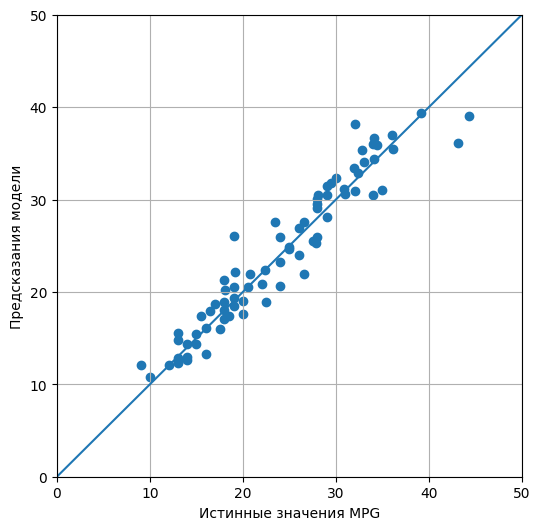

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(test_labels, test_predictions)
plt.xlabel('Истинные значения MPG')
plt.ylabel('Предсказания модели')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims)
plt.grid(True)
plt.show()

Также посмотрю на ошибки предсказаний.

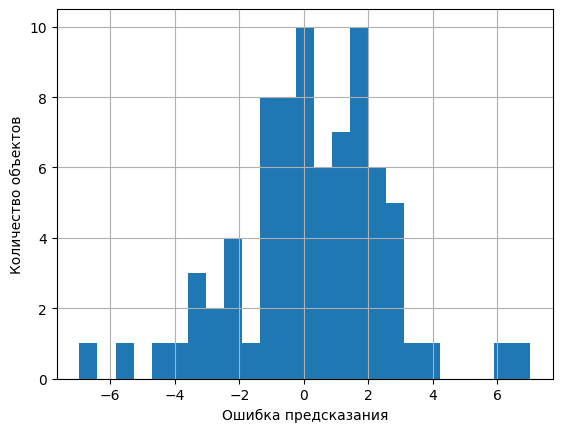

In [29]:
error = test_predictions - test_labels

plt.hist(error, bins=25)
plt.xlabel('Ошибка предсказания')
plt.ylabel('Количество объектов')
plt.grid(True)
plt.show()

Гистограмма ошибок

* ошибки распределены вокруг 0 → модель не даёт систематического смещения;
* большинство ошибок в диапазоне примерно [-3, 3];
* есть редкие большие ошибки (выбросы).

Вывод: модель в целом предсказывает корректно, но есть отдельные неточные случаи.

## 12. Сохранение модели

После обучения модель можно сохранить, чтобы потом использовать без повторного обучения.

In [30]:
dnn_model.save('dnn_model.keras')

In [31]:
reloaded = tf.keras.models.load_model('dnn_model.keras')

reloaded_predictions = reloaded.predict(test_features, verbose=0).flatten()

reloaded_mse = tf.keras.metrics.MeanSquaredError()(test_labels, reloaded_predictions).numpy()
reloaded_mae = tf.losses.MeanAbsoluteError()(test_labels, reloaded_predictions).numpy()

print(f"MSE после загрузки модели: {reloaded_mse:.4f}")
print(f"MAE после загрузки модели: {reloaded_mae:.4f}")

MSE после загрузки модели: 5.3884
MAE после загрузки модели: 1.7546


## Вывод

В этой работе я обучила несколько моделей для задачи регрессии на датасете Auto MPG и сравнила их между собой.

Лучший и наиболее осмысленный вариант для этой задачи — нейронная сеть по всем признакам (`dnn_model`), потому что она использует полную информацию об автомобиле и умеет находить нелинейные зависимости.

Качество итоговой модели я оценила по двум метрикам:
- **MSE** — среднеквадратическая ошибка;
- **MAE** — средняя абсолютная ошибка.

Таким образом, задание на обучение нейронной сети для прогнозирования топливной экономичности автомобилей выполнено.